<a href="https://colab.research.google.com/github/Aghil-hub/Customer_Segmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation for ShopNow

ShopNow is an e-commerce retailer that aims to optimize its marketing strategies by understanding its diverse customer base.

This notebook addresses the business goal of creating distinct customer segments to enable more targeted and effective marketing campaigns. Using a dataset rich with customer demographics, Recency, Frequency, Monetary (RFM) data, engagement metrics, and product category share information, this project builds and interprets K-means clustering segments.

***The insights derived from these segments will inform personalized customer experiences and optimize resource allocation.***

### Key Questions:
* Which customers are high-value / VIPs and how to retain them?
* Which customers are at risk of churning or inactive, and what strategies can re-engage them?
* How do loyal customers differ from those who specialize in specific product categories?
* What actionable marketing strategies can be developed for each identified customer segment?

## **1.0 Environment Setup – Data, Stats, and ML Libraries**

In [1]:
# Load libraries
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
from scipy.stats.mstats import winsorize

#### **1.1 Load ShopNow Customer Dataset from CSV**

In [2]:
# Read data from csv
df = pd.read_csv('ShopNow Dataset.csv')
df.head()

,customer_id,age,gender,income_bucket,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,top_category,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,feedback_text,purchase_next_30d
0,1,40,M,Mid,4,185,80.41,6,2,Groceries,0.031,0.148,0.059,0.253,0.347,0.162,0,"Customer service was unhelpful, slow to respon...",0
1,2,31,M,High,5,146,171.52,6,5,Home,0.273,0.090,0.476,0.031,0.050,0.080,0,"Customer service was unhelpful, slow to respon...",0
2,3,43,F,Low,1,546,22.90,1,7,Groceries,0.071,0.008,0.155,0.275,0.434,0.057,0,"Customer service was unhelpful, slow to respon...",0
3,4,24,M,Low,8,37,38.67,7,4,Home,0.208,0.125,0.272,0.132,0.082,0.181,0,"The quality of the product felt poor, material...",0
4,5,29,F,Low,15,71,49.69,13,5,Sports,0.073,0.084,0.205,0.020,0.293,0.324,0,The price felt fair and reasonable compared to...,0


#### **1.2 Initial Data Sanity Checks (Shape, Types, Missingness)**

In [3]:
df.dtypes

,0
customer_id,int64
age,int64
gender,object
income_bucket,object
orders_last_12m,int64
recency_days,int64
avg_order_value,float64
website_visits_30d,int64
email_opens_90d,int64
top_category,object


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            6000 non-null   int64  
 1   age                    6000 non-null   int64  
 2   gender                 6000 non-null   object 
 3   income_bucket          6000 non-null   object 
 4   orders_last_12m        6000 non-null   int64  
 5   recency_days           6000 non-null   int64  
 6   avg_order_value        6000 non-null   float64
 7   website_visits_30d     6000 non-null   int64  
 8   email_opens_90d        6000 non-null   int64  
 9   top_category           6000 non-null   object 
 10  cat_share_electronics  6000 non-null   float64
 11  cat_share_apparel      6000 non-null   float64
 12  cat_share_home         6000 non-null   float64
 13  cat_share_beauty       6000 non-null   float64
 14  cat_share_groceries    6000 non-null   float64
 15  cat_

There are no null values in the features

In [5]:
df.describe()

,customer_id,age,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,cat_share_electronics,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,purchase_next_30d
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,34.790333,5.29150,199.697667,85.698848,6.501500,5.006000,0.170614,0.168922,0.164107,0.165909,0.165100,0.165338,0.413667,0.225833
std,1732.195139,9.610659,4.07365,221.777102,70.370202,4.767751,2.221738,0.142822,0.142138,0.140662,0.143195,0.139217,0.141137,0.492531,0.418165
min,1.000000,18.000000,0.00000,5.000000,10.620000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1500.750000,28.000000,2.00000,52.000000,33.640000,2.000000,3.000000,0.059000,0.058000,0.056000,0.054000,0.055000,0.055000,0.000000,0.000000
50%,3000.500000,34.500000,5.00000,96.000000,51.420000,6.000000,5.000000,0.133000,0.130000,0.125500,0.126000,0.127000,0.126000,0.000000,0.000000
75%,4500.250000,41.000000,8.00000,310.000000,104.285000,10.000000,6.000000,0.247000,0.244000,0.237000,0.240000,0.243000,0.240000,1.000000,0.000000
max,6000.000000,72.000000,22.00000,799.000000,341.670000,24.000000,15.000000,0.799000,0.813000,0.767000,0.862000,0.824000,0.796000,1.000000,1.000000


Visualizing outliers in RFM variables

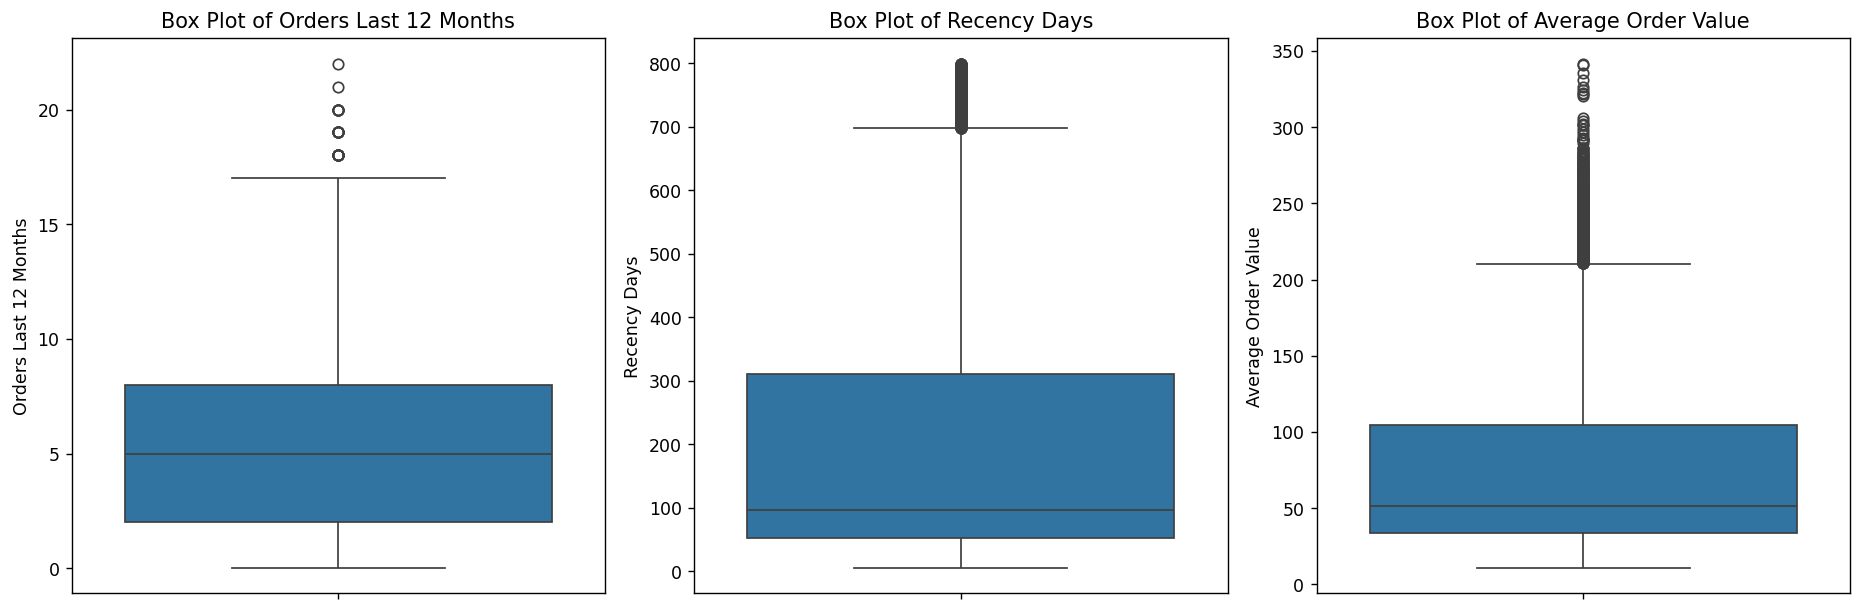

In [6]:
#Boxplots to check for outliers
plt.figure(figsize=(15, 5), dpi=125)

plt.subplot(1, 3, 1)
sns.boxplot(y=df['orders_last_12m'])
plt.title('Box Plot of Orders Last 12 Months')
plt.ylabel('Orders Last 12 Months')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['recency_days'])
plt.title('Box Plot of Recency Days')
plt.ylabel('Recency Days')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['avg_order_value'])
plt.title('Box Plot of Average Order Value')
plt.ylabel('Average Order Value')

plt.tight_layout()
plt.show()

Visualizing skewness

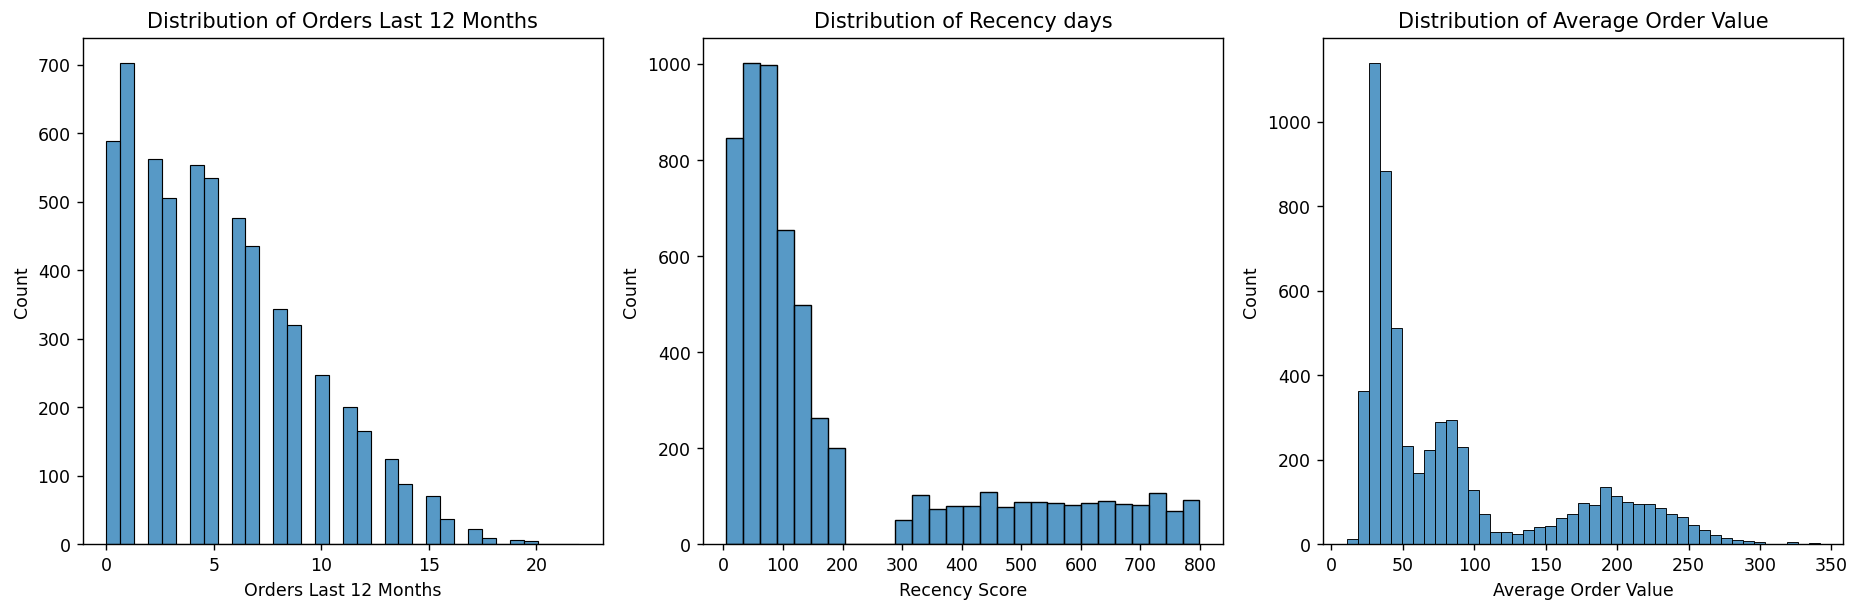

In [7]:
# histograms for discovering skewness
plt.figure(figsize=(15, 5), dpi=125)

plt.subplot(1, 3, 1)
sns.histplot(df['orders_last_12m'])
plt.title('Distribution of Orders Last 12 Months')
plt.xlabel('Orders Last 12 Months')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(df['recency_days'])
plt.title('Distribution of Recency days')
plt.xlabel('Recency Score')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(df['avg_order_value'])
plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Count')

plt.tight_layout()
plt.show()



---



## **2.0 Baseline Segmentation Model with RFM**

This baseline model provides a fundamental understanding of customer value based on Recency, Frequency, Monetary (RFM), serving as a first look at high-value versus low-value segments.

#### **2.1 Create a subset with RFM variables (recency_days, orders_last_12m, avg_order_value)**

In [8]:
rfm = df[['recency_days','orders_last_12m','avg_order_value']].copy()

# Inverting values to align the scale with convention where higher scores always represent more desirable, recently active customers
rfm['recency_score'] = rfm['recency_days'].max() - rfm['recency_days']

rfm.drop(columns=['recency_days'],inplace=True)
rfm.head()

,orders_last_12m,avg_order_value,recency_score
0,4,80.41,614
1,5,171.52,653
2,1,22.90,253
3,8,38.67,762
4,15,49.69,728


#### **2.2 Data Cleaning for RFM Features**

#### 2.21 Handle Outliers

Outliers can disproportionately influence clustering algorithms, pulling cluster centroids away from the true center of the data.

**Winsorization** is applied to cap extreme values in the `avg_order_value`, `recency_score`, and `orders_last_12m` features. This ensures that the clustering model is robust and not unduly affected by a few abnormal data points, leading to more representative clusters.

In [9]:
## Winsorizing
## Average Order Value: Cap both ends (5% each)
rfm['avg_order_value'] = winsorize(rfm['avg_order_value'], limits=[0.05, 0.05])

# Recency: Cap ONLY the top (the most inactive)
rfm['recency_score'] = winsorize(rfm['recency_score'], limits=[0.05, 0.0])

# Frequency: Cap ONLY the top (the extreme power users)
rfm['orders_last_12m'] = winsorize(rfm['orders_last_12m'], limits=[0.0, 0.01])

In [10]:
rfm.describe()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,orders_last_12m,avg_order_value,recency_score
count,6000.000000,6000.000000,6000.000000
mean,5.276000,84.734365,601.612667
std,4.027223,67.554374,216.107631
min,0.000000,25.370000,95.000000
25%,2.000000,33.640000,489.000000
50%,5.000000,51.420000,703.000000
75%,8.000000,104.285000,747.000000
max,16.000000,233.230000,794.000000


#### 2.22 Transform and Scale Features

Before clustering, features are **log-transformed** to reduce skewness, especially in `avg_order_value` and `orders_last_12m`, which often exhibit skewed distributions in real-world data.

Subsequently, `StandardScaler` is applied to scale the data, ensuring all features contribute equally to the distance calculations during clustering by having a mean of 0 and standard deviation of 1.

In [11]:
# Check skewness of the model features
print(rfm[['orders_last_12m', 'avg_order_value', 'recency_score']].skew())

orders_last_12m    0.650449
avg_order_value    1.109426
recency_score     -1.294224
dtype: float64


**avg_order_value and orders_last_12m are right skewed**

In [12]:
# Apply Log Transformation to right-skewed features
rfm['avg_order_value'] = np.log1p(rfm['avg_order_value'])
rfm['orders_last_12m'] = np.log1p(rfm['orders_last_12m'])

# Re-check skewness to confirm improvement
print("New Skewness:")
print(rfm[['orders_last_12m', 'avg_order_value', 'recency_score']].skew())

New Skewness:
orders_last_12m   -0.568199
avg_order_value    0.504312
recency_score     -1.294224
dtype: float64


**Right skewness reduced for both variables**

In [13]:
# Scale the variables
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled

array([[ 0.03615122,  0.31081986,  0.05732498],
       [ 0.27024003,  1.34976546,  0.23780565],
       [-1.14030541, -1.24863405, -1.61327816],
       ...,
       [ 0.03615122,  0.21405226,  0.47844655],
       [ 1.26296465, -0.82531691,  0.46919113],
       [-1.14030541, -1.0168475 , -2.34445626]])

In [14]:
# check if scaled correctly
rfm_scaled.mean(axis=0)

array([ 3.31586610e-17, -7.14391509e-16,  4.32246831e-17])

In [15]:
# check if scaled correctly
rfm_scaled.std(axis=0,ddof=0)

array([1., 1., 1.])

#### **2.3 Choose Number of Clusters (Elbow Method)**

The Elbow Method is employed to determine the optimal number of clusters (k) for K-means. It plots the within-cluster sum of squares (inertia) against the number of clusters. The 'elbow point' in the graph, where the rate of decrease in inertia sharply changes, indicates a suitable number of clusters where adding more clusters doesn't significantly improve the model fit.

In [16]:
# calculate inertia with k from 2 to 10
inertia = []
for k in range(2,10):
  kmeans = KMeans(n_clusters=k,n_init=20,random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

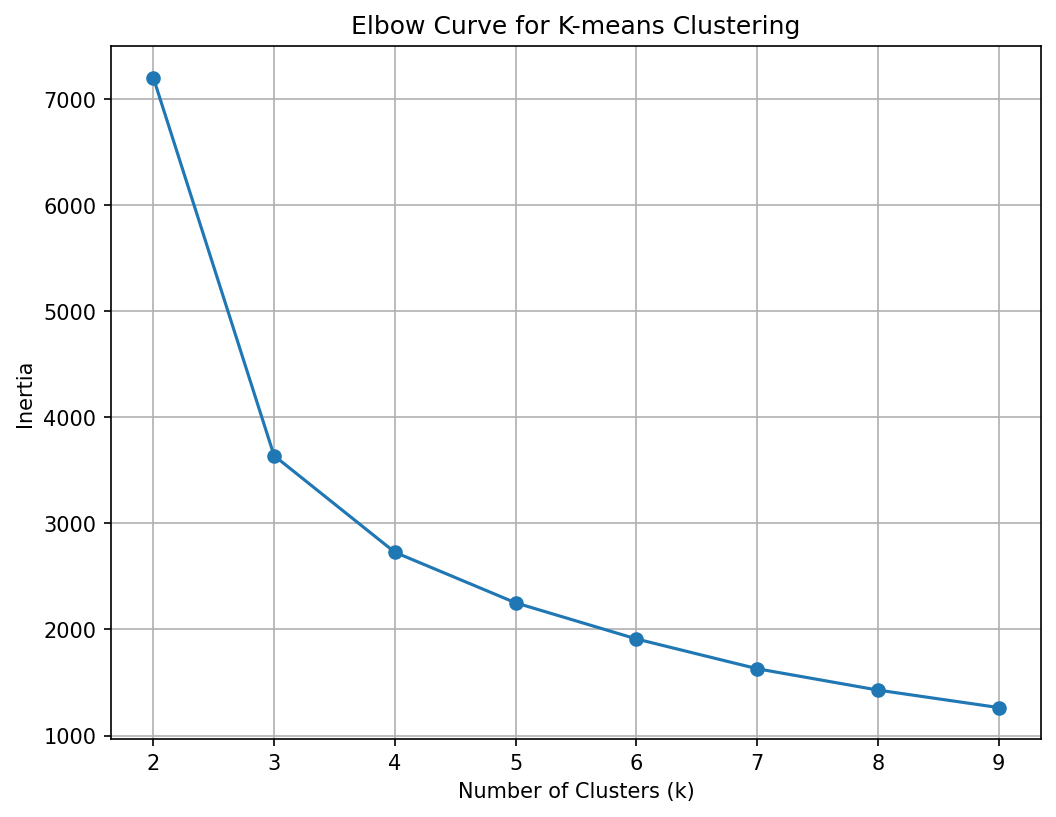

In [17]:
# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

**Choosing k = 4**

At k = 4, the elbow curve shows a clear flattening in the reduction of inertia, meaning additional clusters yield only marginal improvements in within-cluster compactness. This value of k also produces four interpretable and business-relevant segments (e.g., VIPs, at-risk, loyal, specialists) without over-fragmenting the customer base.

In [18]:
# Perform K-means clustering with best K (k = 4)
best_kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
rfm['Cluster'] = best_kmeans.fit_predict(rfm_scaled)

In [19]:
# Group by cluster and calculate mean values
cluster_summary = rfm.groupby('Cluster').agg({
    'recency_score': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean'
}).reset_index()
print(cluster_summary)


   Cluster  recency_score  orders_last_12m  avg_order_value
0        0     718.997869         1.511363         5.275202
1        1     258.211213         0.575061         3.436816
2        2     747.160414         2.385225         3.707814
3        3     691.878968         1.845229         4.376367


#### **2.4 Profile RFM Clusters**

After clustering, the average `recency_score`, `orders_last_12m`, and `avg_order_value` for each cluster are calculated and visualized. This profiling step is crucial for understanding the distinct characteristics of each segment. By examining these metrics, I can identify which clusters represent high-value, frequent, or recent customers, as well as those that might be at risk or less engaged.

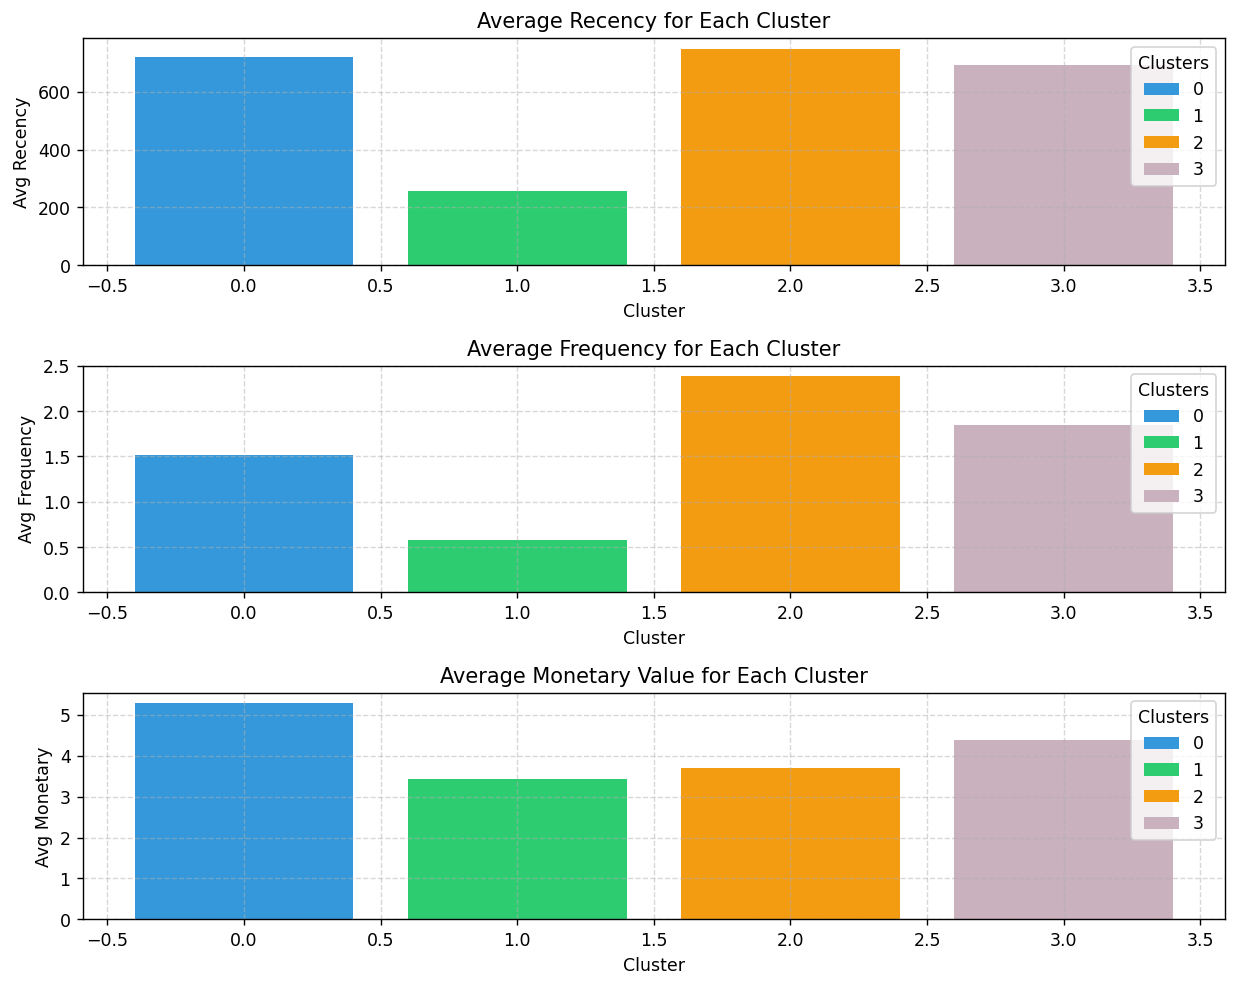

In [20]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 8),dpi=125)

# Plot Avg Recency
plt.subplot(3, 1, 1)
bars = plt.bar(cluster_summary.index, cluster_summary['recency_score'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(3, 1, 2)
bars = plt.bar(cluster_summary.index, cluster_summary['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(3, 1, 3)
bars = plt.bar(cluster_summary.index, cluster_summary['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary.index, title='Clusters')

plt.tight_layout()
plt.show()

The baseline RFM model successfully groups customers into four distinct segments based on their recency, purchase frequency, and monetary value, giving us a first view of VIPs, loyal, and at-risk customers. **However, because it ignores what customers buy, two shoppers with similar RFM profiles but very different category preferences can end up in the same cluster.** This limitation motivates the enhanced model in the next section.



---



## **3.0 Enhanced Segmentation with Category Behaviour**

By incorporating **category concentration or entropy**, I can distinguish between 'Generalists' who shop across the store and 'Specialists' who are highly loyal to a specific niche. This section re-runs the K-means algorithm with this richer feature set to create more actionable segments.

#### **3.1 Build Category Behaviour Feature**

**Shannon Entropy is used to measure the diversity of a customer's purchases across all product categories. A high entropy score indicates a broad shopper, while a low score (high category concentration) identifies a customer who focuses their spending on just one or two specific areas.**

In [21]:
# Create a new entropy feature by combining category share columns

cat_cols = ["cat_share_electronics","cat_share_apparel","cat_share_home","cat_share_beauty","cat_share_groceries","cat_share_sports"]

def category_entropy(row):
    p = row[cat_cols].values
    p = np.array(p, dtype=np.float64)
    epsilon = 1e-10
    p = p + epsilon
    return entropy(p, base=2)

df["category_entropy"] = df.apply(category_entropy, axis=1)

max_entropy = np.log2(len(cat_cols))
df["category_concentration"] = 1 - df["category_entropy"] / max_entropy

df.head()

,customer_id,age,gender,income_bucket,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,top_category,...,cat_share_apparel,cat_share_home,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,feedback_text,purchase_next_30d,category_entropy,category_concentration
0,1,40,M,Mid,4,185,80.41,6,2,Groceries,...,0.148,0.059,0.253,0.347,0.162,0,"Customer service was unhelpful, slow to respon...",0,2.261115,0.125281
1,2,31,M,High,5,146,171.52,6,5,Home,...,0.090,0.476,0.031,0.050,0.080,0,"Customer service was unhelpful, slow to respon...",0,1.996734,0.227558
2,3,43,F,Low,1,546,22.90,1,7,Groceries,...,0.008,0.155,0.275,0.434,0.057,0,"Customer service was unhelpful, slow to respon...",0,2.013961,0.220894
3,4,24,M,Low,8,37,38.67,7,4,Home,...,0.125,0.272,0.132,0.082,0.181,0,"The quality of the product felt poor, material...",0,2.484929,0.038698
4,5,29,F,Low,15,71,49.69,13,5,Sports,...,0.084,0.205,0.020,0.293,0.324,0,The price felt fair and reasonable compared to...,0,2.203861,0.147430


In [22]:
df[['category_entropy','category_concentration']].describe()

,category_entropy,category_concentration
count,6000.000000,6000.000000
mean,2.089782,0.191562
std,0.252025,0.097497
min,0.828960,0.005328
25%,1.946438,0.119610
50%,2.126282,0.177442
75%,2.275775,0.247015
max,2.571189,0.679315


#### **3.2 Create a subset with RFM variables (recency_days, orders_last_12m, avg_order_value) + Category Concentration variable**

In [23]:
# Create a subset
all_var = df[['recency_days','orders_last_12m','avg_order_value','category_concentration']].copy()

# Inverting values to align the scale with convention where higher scores always represent more desirable, recently active customers
all_var['recency_score'] = all_var['recency_days'].max() - all_var['recency_days']

all_var.drop(columns=['recency_days'],inplace=True)

all_var.head()

,orders_last_12m,avg_order_value,category_concentration,recency_score
0,4,80.41,0.125281,614
1,5,171.52,0.227558,653
2,1,22.90,0.220894,253
3,8,38.67,0.038698,762
4,15,49.69,0.147430,728


#### **3.3 Data Cleaning for RFM + Category Features**
This block mirrors the outlier handling and transformations from the baseline model, extended to the richer RFM + category concentration feature set.

#### 3.31 Handle Outliers

In [24]:
## Winsorizing
## Average Order Value: Cap both ends (5% each)
all_var['avg_order_value'] = winsorize(all_var['avg_order_value'], limits=[0.05, 0.05])

# Recency: Cap ONLY the top (the most inactive)
all_var['recency_score'] = winsorize(all_var['recency_score'], limits=[0.05, 0.0])

# Frequency: Cap ONLY the top (the extreme power users)
all_var['orders_last_12m'] = winsorize(all_var['orders_last_12m'], limits=[0.0, 0.01])

#### 3.32 Transform and Scale Features

In [25]:
# Log Transform the right-skewed RFM columns
all_var['avg_order_value'] = np.log1p(all_var['avg_order_value'])
all_var['orders_last_12m'] = np.log1p(all_var['orders_last_12m'])

In [26]:
# Scale the variables
all_var_scaled = scaler.fit_transform(all_var)
all_var_scaled

array([[ 0.03615122,  0.31081986, -0.67988331,  0.05732498],
       [ 0.27024003,  1.34976546,  0.36922992,  0.23780565],
       [-1.14030541, -1.24863405,  0.30087219, -1.61327816],
       ...,
       [ 0.03615122,  0.21405226, -0.37045814,  0.47844655],
       [ 1.26296465, -0.82531691, -0.00813083,  0.46919113],
       [-1.14030541, -1.0168475 , -0.93788856, -2.34445626]])

In [27]:
# check if scaled correctly
all_var_scaled.mean(axis=0)

array([ 3.31586610e-17, -7.14391509e-16, -1.77635684e-17,  4.32246831e-17])

In [28]:
# check if scaled correctly
all_var_scaled.std(axis=0,ddof=0)

array([1., 1., 1., 1.])

#### **3.4 Choose Number of Clusters (Elbow Method)**
This block mirrors the 'Choose the Number of Clusters' section from the baseline model, extended to the richer RFM + category concentration feature set.

In [29]:
# calculate inertia with k from 2 to 10
inertia_a = []
for k in range(2,10):
  kmeans_a = KMeans(n_clusters=k,n_init=20,random_state=42)
  kmeans_a.fit(all_var_scaled)
  inertia_a.append(kmeans_a.inertia_)

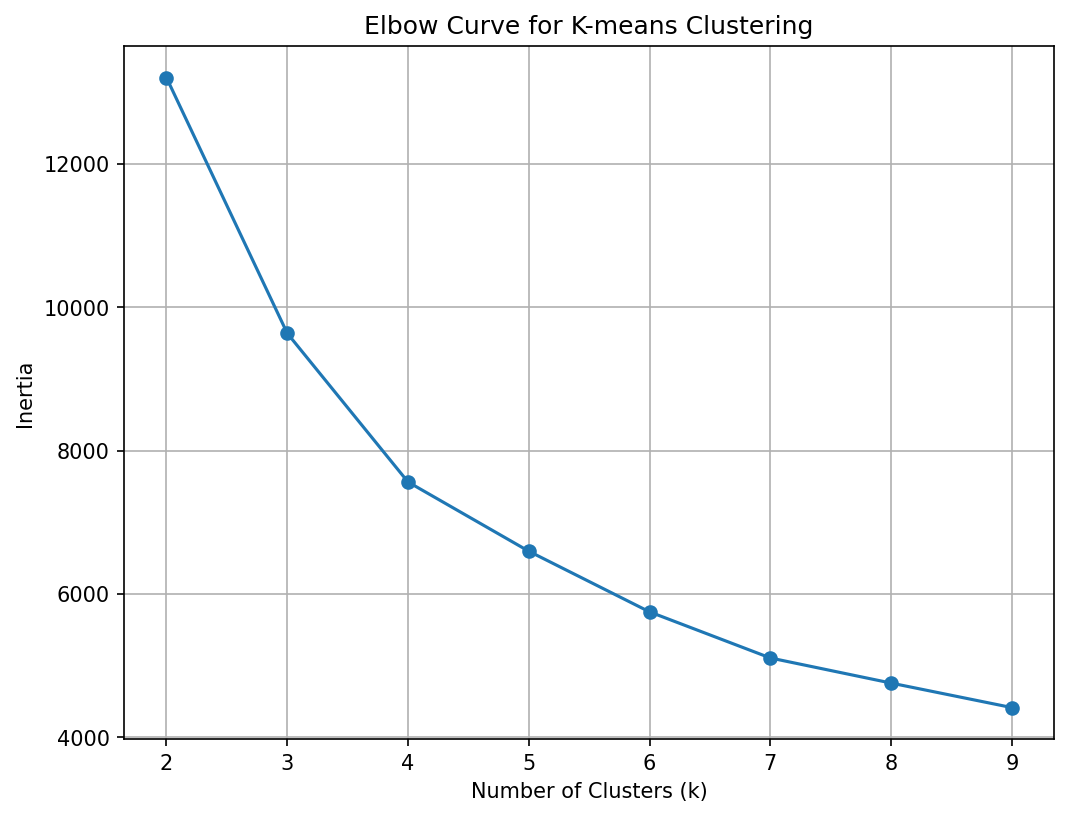

In [30]:
# Plot the elbow curve
plt.figure(figsize=(8, 6),dpi=150)
plt.plot(range(2, 10), inertia_a, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)
plt.show()

**Choosing k = 4**

At k = 4, the elbow curve for the enhanced feature set (RFM plus category concentration) shows a clear flattening in inertia, indicating that additional clusters provide only marginal gains in fit. With four clusters, the segments remain easy to interpret and differentiate not just by value (recency, frequency, monetary) but also by whether customers behave like broad “generalists” or focused “category specialists,” making the resulting personas both stable and highly actionable for marketing.

In [31]:
# Perform K-means clustering with best K (k = 4)
best_kmeans_a = KMeans(n_clusters=4, n_init=20, random_state=42)
all_var['Cluster'] = best_kmeans_a.fit_predict(all_var_scaled)

In [32]:
# Group by cluster and calculate mean values
cluster_summary_a = all_var.groupby('Cluster').agg({
    'recency_score': 'mean',
    'orders_last_12m': 'mean',
    'avg_order_value': 'mean',
    'category_concentration': 'mean'
}).reset_index()
print(cluster_summary_a)


   Cluster  recency_score  orders_last_12m  avg_order_value  \
0        0     715.260179         1.495380         5.164965   
1        1     256.610013         0.569292         3.436452   
2        2     723.792118         2.194010         3.967042   
3        3     712.295115         1.996866         4.282396   

   category_concentration  
0                0.162746  
1                0.191138  
2                0.143922  
3                0.330254  


#### **3.5 Profile RFM + Category Clusters**

After clustering on the enhanced feature set, the average recency_score, orders_last_12m, avg_order_value, and category_concentration for each cluster are calculated and visualized. This profiling step is crucial for understanding not only which segments are recent, frequent, and high-spending, **but also whether they behave like broad generalists or focused category specialists**. By examining these metrics together, I can distinguish VIPs, at-risk, loyal, and specialist customers in a way that directly supports targeted merchandising and marketing strategies.

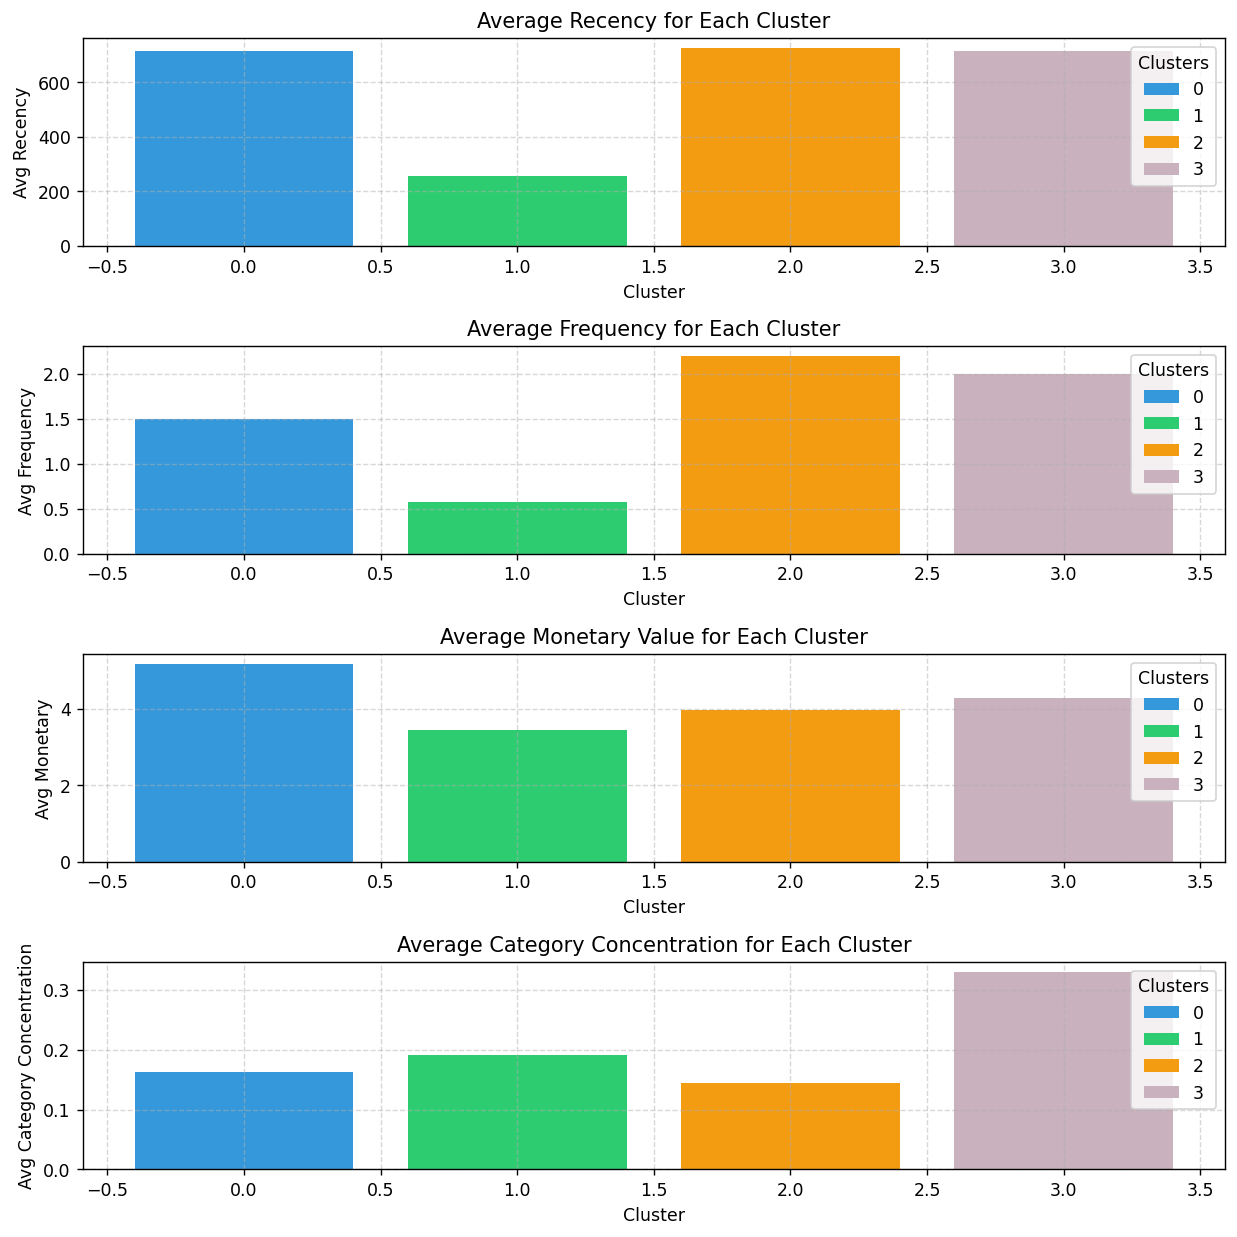

In [33]:
colors = ['#3498db', '#2ecc71', '#f39c12','#C9B1BD']

# Plot the average RFM scores for each cluster
plt.figure(figsize=(10, 10),dpi=125)

# Plot Avg Recency
plt.subplot(4, 1, 1)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['recency_score'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Recency')
plt.title('Average Recency for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

# Plot Avg Frequency
plt.subplot(4, 1, 2)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['orders_last_12m'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Frequency')
plt.title('Average Frequency for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

# Plot Avg Monetary
plt.subplot(4, 1, 3)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['avg_order_value'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Monetary')
plt.title('Average Monetary Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

# Plot Avg Category Concentration
plt.subplot(4, 1, 4)
bars = plt.bar(cluster_summary_a.index, cluster_summary_a['category_concentration'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg Category Concentration')
plt.title('Average Category Concentration for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_summary_a.index, title='Clusters')

plt.tight_layout()
plt.show()

#### 3.51 Name the Segments

Based on the cluster means, I can identify four distinct customer personas:
* **Segment 0 – Recent High Spenders (VIPs):** High average order value and frequent recent purchases.
* **Segment 1 – Inactive / At-Risk:** Very high recency (days since last purchase) and minimal recent order volume.
* **Segment 2 – Loyal Customers:** High frequency and low recency, showing consistent engagement over time.
* **Segment 3 – Category Specialists:** High category concentration, indicating they primarily shop in one specific product area.



---



## **4.0 Who Are These Segments?**

To make these segments actionable for the marketing team, I analyze the underlying demographics of the enhanced segmentation model. By observing differences in age, gender, and income across clusters, I can tailor the tone and platform of ShopNow's campaigns to match the specific profile of each group.

**Add 'Cluster' column to the original dataset**

In [34]:
# Add the 'Cluster' column from all_var to the original df DataFrame
df['Cluster_Model2'] = all_var['Cluster']

cluster_descriptions = {
    0: 'Recent High Spenders (VIPs)',
    1: 'Inactive/At-Risk Customers',
    2: 'Loyal Customers',
    3: 'Category Specialists'
}

df['Cluster_Desc'] = df['Cluster_Model2'].map(cluster_descriptions)

# Display the first few rows of df with the new Cluster column
display(df.head())

,customer_id,age,gender,income_bucket,orders_last_12m,recency_days,avg_order_value,website_visits_30d,email_opens_90d,top_category,...,cat_share_beauty,cat_share_groceries,cat_share_sports,discount_exposed_30d,feedback_text,purchase_next_30d,category_entropy,category_concentration,Cluster_Model2,Cluster_Desc
0,1,40,M,Mid,4,185,80.41,6,2,Groceries,...,0.253,0.347,0.162,0,"Customer service was unhelpful, slow to respon...",0,2.261115,0.125281,2,Loyal Customers
1,2,31,M,High,5,146,171.52,6,5,Home,...,0.031,0.050,0.080,0,"Customer service was unhelpful, slow to respon...",0,1.996734,0.227558,0,Recent High Spenders (VIPs)
2,3,43,F,Low,1,546,22.90,1,7,Groceries,...,0.275,0.434,0.057,0,"Customer service was unhelpful, slow to respon...",0,2.013961,0.220894,1,Inactive/At-Risk Customers
3,4,24,M,Low,8,37,38.67,7,4,Home,...,0.132,0.082,0.181,0,"The quality of the product felt poor, material...",0,2.484929,0.038698,2,Loyal Customers
4,5,29,F,Low,15,71,49.69,13,5,Sports,...,0.020,0.293,0.324,0,The price felt fair and reasonable compared to...,0,2.203861,0.147430,2,Loyal Customers


**Avg RFM by segments (real-world scale)**

In [35]:
# Check real-world averages for your new descriptions
df.groupby('Cluster_Desc')[['recency_days', 'orders_last_12m', 'avg_order_value']].mean()

,recency_days,orders_last_12m,avg_order_value
Cluster_Desc,,,
Category Specialists,86.704885,7.176471,86.824407
Inactive/At-Risk Customers,551.521739,0.980896,29.893722
Loyal Customers,75.207882,8.583251,55.446251
Recent High Spenders (VIPs),83.739821,3.890959,185.765114


Looking at average recency, frequency, and monetary value by segment, I see clear separation in how each group behaves commercially.
1. **Recent High Spenders (VIPs)** cluster at the top on spend and above-average order frequency.
2. **Loyal Customers** show strong frequency but more moderate basket sizes.
3. **Inactive/At-Risk Customers** trail on both frequency and spend and have gone much longer since their last purchase.
4. **Category Specialists** sit in the middle on value but are defined by their focused category behavior rather than raw RFM alone.

**Count of customers in each segment**

In [36]:
# group by cluster and aggregate by customer_id
cluster_count = df.groupby(['Cluster_Desc'])['customer_id'].count().reset_index()
display(cluster_count.head())

,Cluster_Desc,customer_id
0,Category Specialists,1003
1,Inactive/At-Risk Customers,1518
2,Loyal Customers,2030
3,Recent High Spenders (VIPs),1449


/tmp/ipykernel_25459/2403016136.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster_Desc', palette='viridis', order=cluster_order)


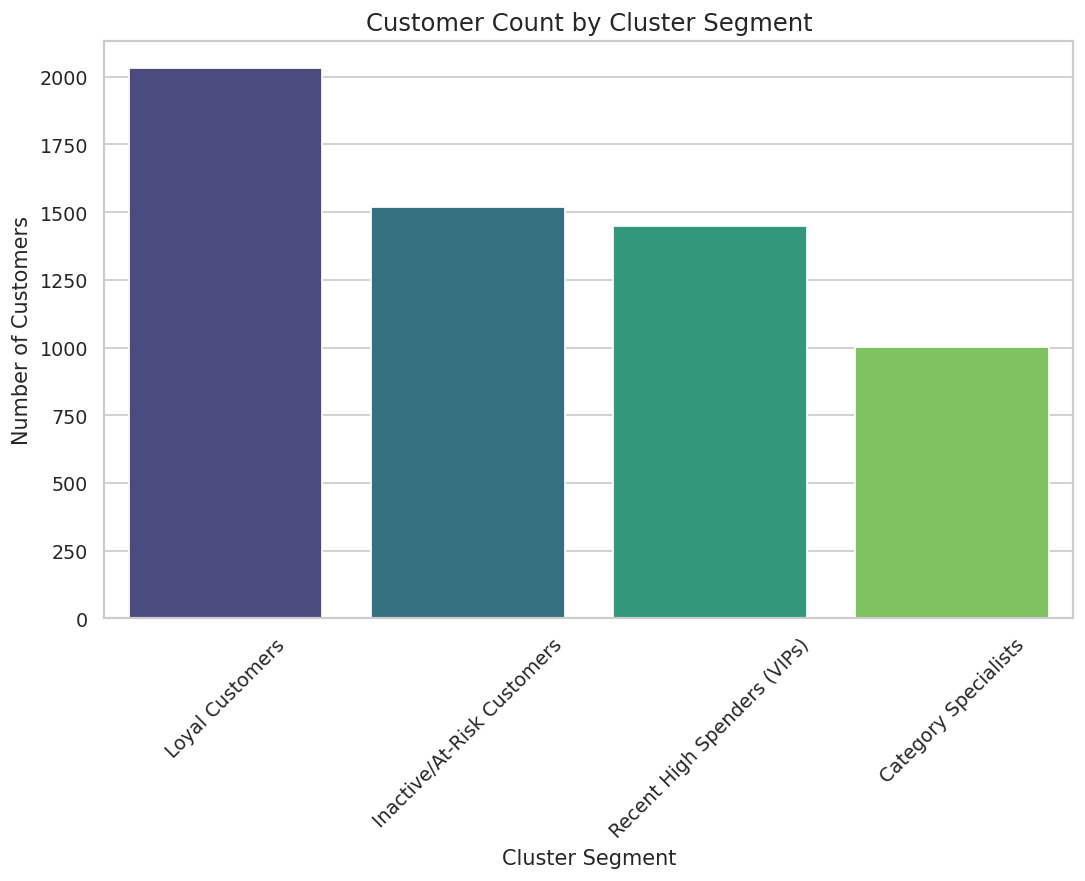

In [37]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Visualize the Size of Each Cluster (Overall Distribution)
plt.figure(figsize=(10, 6), dpi=125)
cluster_order = df['Cluster_Desc'].value_counts().index # Sort by largest cluster
sns.countplot(data=df, x='Cluster_Desc', palette='viridis', order=cluster_order)

plt.title('Customer Count by Cluster Segment', fontsize=14)
plt.xlabel('Cluster Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Most ShopNow customers are Loyal customers and the fewest customers are Category Specialists

**Category distribution in each segment**

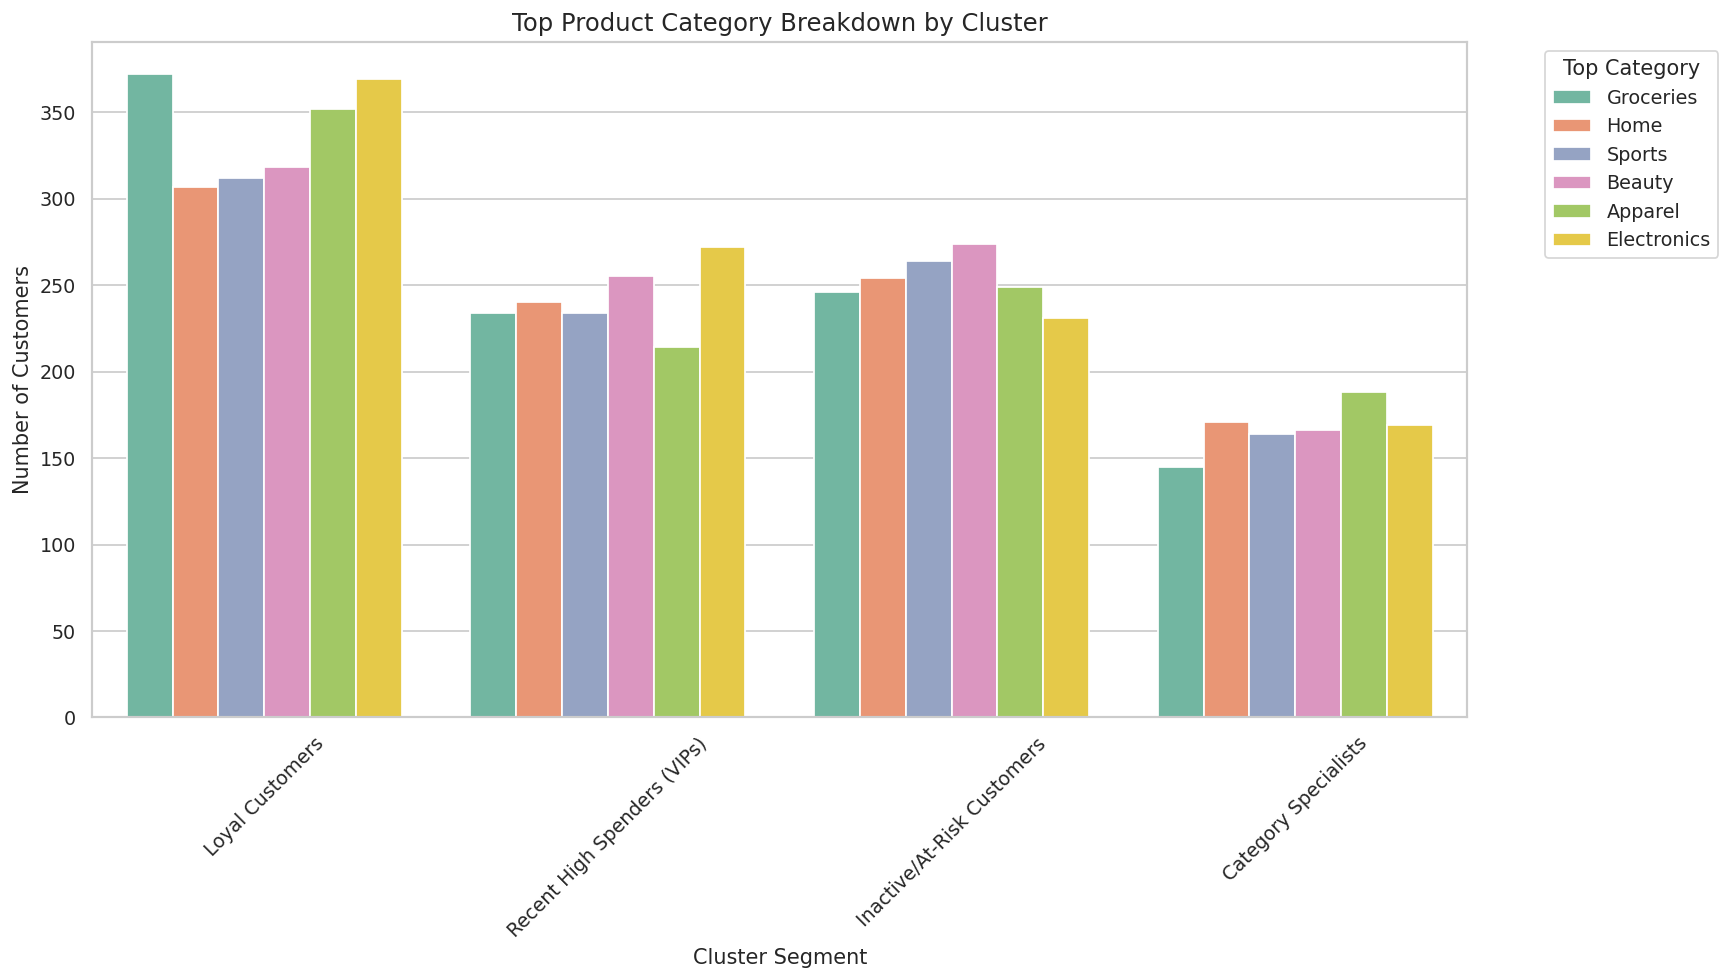

In [38]:
# Visualize Top Category Distribution within Each Cluster
# This is especially useful for profiling your "Category Specialists"
plt.figure(figsize=(14, 8), dpi=125)
sns.countplot(data=df, x='Cluster_Desc', hue='top_category', palette='Set2')

plt.title('Top Product Category Breakdown by Cluster', fontsize=14)
plt.xlabel('Cluster Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Top Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product categories are fairly even across all segments, with no single category dominating any one cluster.

**Avg age by segments**

In [39]:
cluster_age_summary = df.groupby(['Cluster_Desc'])['age'].mean().reset_index()
display(cluster_age_summary.head())

,Cluster_Desc,age
0,Category Specialists,34.878365
1,Inactive/At-Risk Customers,34.727931
2,Loyal Customers,34.964039
3,Recent High Spenders (VIPs),34.551415


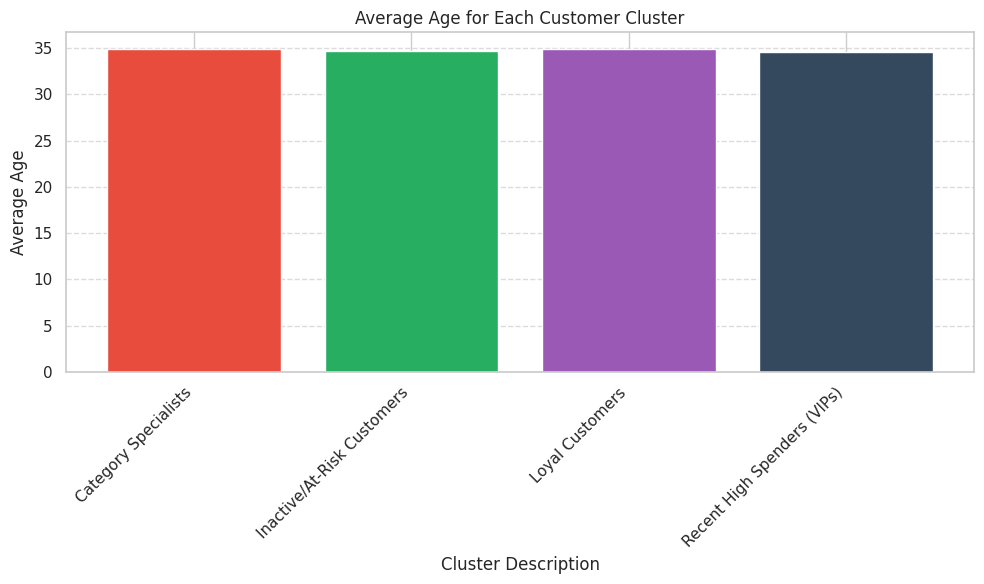

In [40]:
plt.figure(figsize=(10, 6), dpi=100)
plt.bar(cluster_age_summary['Cluster_Desc'], cluster_age_summary['age'], color=['#e74c3c', '#27ae60', '#9b59b6', '#34495e'])
plt.xlabel('Cluster Description')
plt.ylabel('Average Age')
plt.title('Average Age for Each Customer Cluster')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Average age is tightly clustered around 35 across all segments, suggesting that age is not a primary driver of differences in shopping behavior for these clusters.

**Gender distribution in each segment**

In [41]:
# Count of gender by Cluster_Desc
gender_by_cluster = df.groupby(['Cluster_Desc', 'gender']).size().reset_index(name='count')
# Transpose gender_by_cluster
gender_by_cluster_transposed = gender_by_cluster.pivot_table(index='Cluster_Desc', columns='gender', values='count', fill_value=0)
display(gender_by_cluster_transposed.head())

gender,F,M
Cluster_Desc,,
Category Specialists,502.0,501.0
Inactive/At-Risk Customers,752.0,766.0
Loyal Customers,1034.0,996.0
Recent High Spenders (VIPs),708.0,741.0


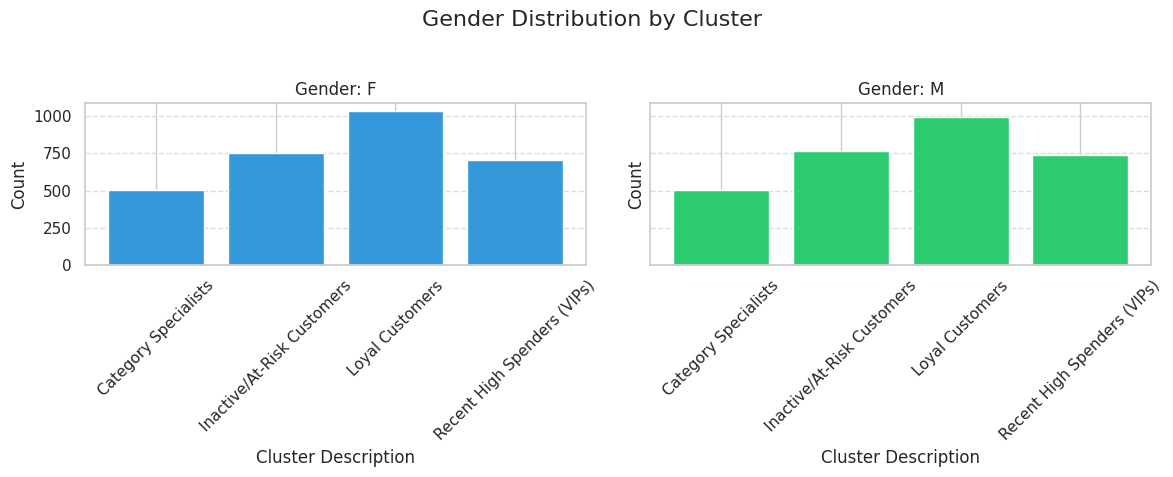

In [42]:
# Plotting Gender Distribution by Cluster
fig, axes = plt.subplots(nrows=1, ncols=len(gender_by_cluster_transposed.columns), figsize=(12, 5), dpi=100, sharey=True)
fig.suptitle('Gender Distribution by Cluster', fontsize=16)

for i, gender in enumerate(gender_by_cluster_transposed.columns):
    axes[i].bar(gender_by_cluster_transposed.index, gender_by_cluster_transposed[gender], color=colors[i % len(colors)])
    axes[i].set_xlabel('Cluster Description')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'Gender: {gender}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Gender distribution is balanced within each segment (similar counts of male and female customers).

**Income bucket distribution for each segment**

In [43]:
# Count of income_bucket by Cluster_Desc
income_by_cluster = df.groupby(['Cluster_Desc', 'income_bucket']).size().reset_index(name='count')
# Transpose income_by_cluster
income_by_cluster_transposed = income_by_cluster.pivot_table(index='Cluster_Desc', columns='income_bucket', values='count', fill_value=0)
display(income_by_cluster_transposed.head())

income_bucket,High,Low,Mid
Cluster_Desc,,,
Category Specialists,189.0,296.0,518.0
Inactive/At-Risk Customers,288.0,467.0,763.0
Loyal Customers,402.0,603.0,1025.0
Recent High Spenders (VIPs),257.0,449.0,743.0


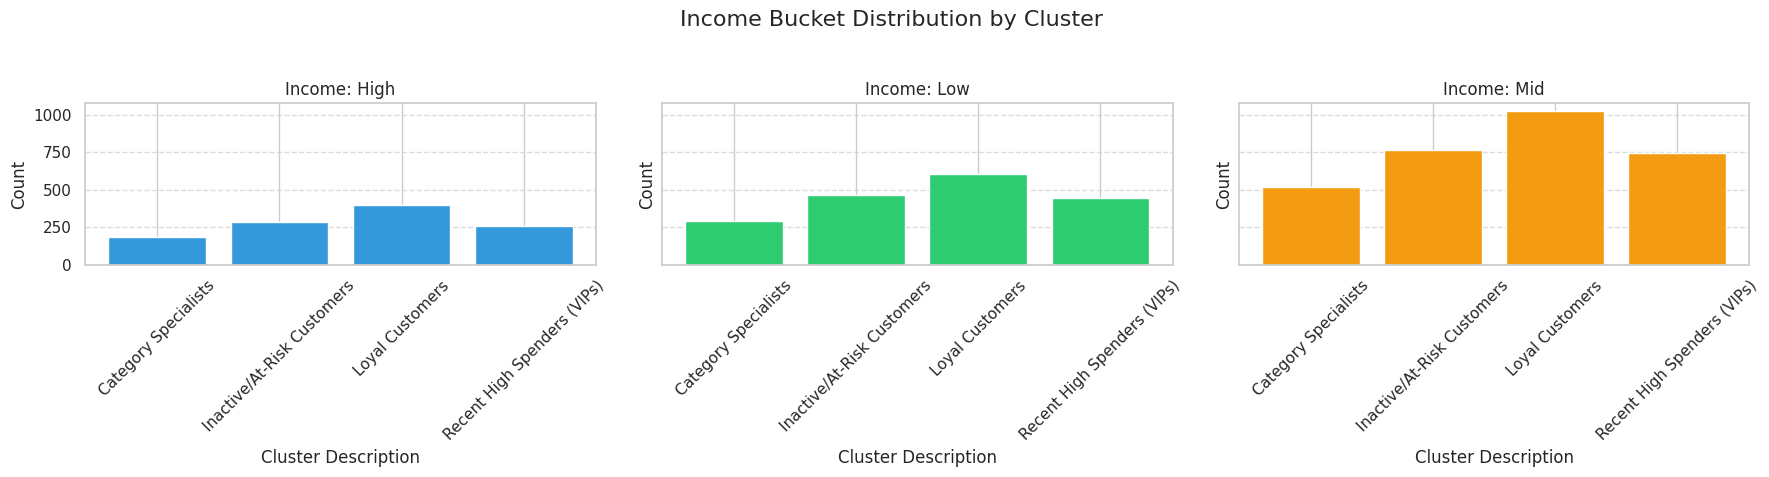

In [44]:
# Plotting Income Bucket Distribution by Cluster
fig, axes = plt.subplots(nrows=1, ncols=len(income_by_cluster_transposed.columns), figsize=(18, 5), dpi=100, sharey=True)
fig.suptitle('Income Bucket Distribution by Cluster', fontsize=16)

for i, income_bucket in enumerate(income_by_cluster_transposed.columns):
    axes[i].bar(income_by_cluster_transposed.index, income_by_cluster_transposed[income_bucket], color=colors[i % len(colors)])
    axes[i].set_xlabel('Cluster Description')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'Income: {income_bucket}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

All segments have a mix of Low, Mid, and High income customers with a tilt toward Mid income.

Customers in all four segments show clear differences in how they buy but are demographically similar, which means behavior is doing the heavy lifting in this segmentation not age, gender, or income.



---



## **5.0 Marketing Actions by Segment**

**Recent High Spenders (VIPs)**
* Offer early access to new collections and high-tier rewards to maintain loyalty.
* Use personalized services and/or dedicated support to make them feel valued and protect this high-value segment from churn.

**Inactive / At-Risk Customers**
* Deploy win-back campaigns offering aggressive discount codes to re-engage these customers
* Conduct surveys to understand why they stopped shopping.

**Loyal Customers**
* Use cross-sell recommendations to introduce them to categories they haven't tried yet.
* Implement a points-based loyalty program to reward consistent frequency and nudge them further up the value ladder.

**Category Specialists**
* Send category-specific newsletters (e.g., only Electronics) aligned with their focused purchasing behaviour.
* Provide bundles or bulk-buy discounts within their preferred category to deepen wallet share without pushing irrelevant products.